# 01 · Calidad de datos y limpieza inicial
Trabajo Práctico Integrador · Analítica Descriptiva · Grupo 6 · PreEntrega 2
Repositorio: https://github.com/fedelachter/AD_Trabajo_Practico_G6

En este notebook revisamos los datos que scrapeamos de MercadoLibre Inmuebles (venta y alquiler en CABA) antes de analizarlos. Queremos saber si se puede confiar en ellos, qué hay que arreglar y cómo queda la versión limpia que van a usar los notebooks siguientes. Cada decisión de limpieza se apoya en algo que medimos antes; no borramos nada de manera automática.

Cada sección sigue el mismo orden: qué queremos saber, con qué datos, qué hicimos, cómo lo controlamos, qué salió y qué significa.

Usamos `mercadolibre_alquiler_caba.csv` y `mercadolibre_venta_caba.csv`, que tienen la misma estructura y se procesan con la misma función de `src/limpieza.py`. Argenprop lo evaluamos aparte (sección 2.9) pero no entra al dataset maestro. El EDA y la normalización monetaria definitiva quedan para después: esta última depende de la cotización que defina el grupo (ver parámetros).

## 1. Configuración e ingesta
Dejamos todo parametrizado en un solo lugar, con rutas relativas al repositorio, y cargamos las dos fuentes con la misma función.

In [ ]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# --- Rutas relativas al repositorio (el notebook vive en /notebooks) ---------------------
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (RAIZ / "src").exists():  # p. ej. en Colab: se clona el repositorio del proyecto
    subprocess.run(["git", "clone", "-q", "https://github.com/fedelachter/AD_Trabajo_Practico_G6"], check=True)
    RAIZ = Path.cwd() / "AD_Trabajo_Practico_G6"
sys.path.append(str(RAIZ))
from src import limpieza as lp

RAW_DIR = RAIZ / "data" / "raw"
PROCESSED_DIR = RAIZ / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# --- Parámetros (todo lo que se puede querer cambiar está acá) ---------------------------
FUENTES = {"alquiler": "mercadolibre_alquiler_caba.csv", "venta": "mercadolibre_venta_caba.csv"}
SEMILLA = 42            # partición train/test reproducible
FRAC_TEST = 0.2
Z_ATIPICO = 4           # umbral del z robusto para marcar precios atípicos
FECHA_CORTE_SCRAPING = "2026-09-07"   # fecha de extracción de los datos (CONFIRMAR con el equipo)
# Tipo de cambio para homogeneizar ARS -> USD: se trae de la API de bluelytics para una fecha
# FIJA (reproducibilidad) usando el dólar BLUE (las operaciones inmobiliarias se liquidan en
# dólar billete, no al oficial). Si la API falla, se usa TC_BLUE_RESPALDO.
FECHA_TIPO_CAMBIO = "2026-10-06"      # fecha de referencia para la cotización
TC_BLUE_RESPALDO = 1545.0             # respaldo si la API no responde (bluelytics, 06/10/2026)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
LOG = []   # registro de cambios: se completa a medida que se limpia

In [2]:
partes = []
for operacion, archivo in FUENTES.items():
    df_op, origen = lp.cargar_fuente(archivo, operacion, RAW_DIR)
    print(f"{operacion:9s} {df_op.shape}  <-  {origen.replace(str(RAIZ), '.')}")
    partes.append(df_op)
crudo = pd.concat(partes, ignore_index=True)

print(f"\nTotal: {crudo.shape[0]:,} avisos x {crudo.shape[1]} columnas")
print("Fecha de corte del scraping:", FECHA_CORTE_SCRAPING or "SIN COMPLETAR (ver parámetros)")
crudo.head(3)

alquiler  (10166, 16)  <-  ./data/raw/mercadolibre_alquiler_caba.csv


venta     (45568, 16)  <-  ./data/raw/mercadolibre_venta_caba.csv

Total: 55,734 avisos x 16 columnas
Fecha de corte del scraping: SIN COMPLETAR (ver parámetros)


,id_aviso,titulo,direccion,barrio,ciudad,moneda,precio,m2_cubiertos,dormitorios,banos,ambientes,tipo_propiedad,link,operacion,es_emprendimiento,fuente
0,MLA3514597138,Departamento En Alquiler En Floresta,"Rivera Indarte Al 100, Floresta, Capital Federal",Floresta,Capital Federal,ARS,650000,40.0,NaN,1.0,20.0,departamento,https://departamento.mercadolibre.com.ar/MLA-3...,alquiler,0,mercadolibre_alquiler_caba.csv
1,MLA3637338538,Excelente 4 Ambientes Amplios - Con Cochera Fi...,"Av. Gaona 4400, Floresta, Capital Federal",Floresta,Capital Federal,ARS,1300000,NaN,NaN,2.0,4.0,departamento,https://departamento.mercadolibre.com.ar/MLA-3...,alquiler,0,mercadolibre_alquiler_caba.csv
2,MLA1911101529,"Alquier Dto 2 Ambientes Con Balcon, Sobre Av. ...",AVENIDA DIRECTORIO Al 3325. Entre Azul Y Perga...,Floresta,Capital Federal,ARS,700000,40.0,NaN,1.0,2.0,departamento,https://departamento.mercadolibre.com.ar/MLA-1...,alquiler,0,mercadolibre_alquiler_caba.csv


Cada fila es un **aviso publicado**, no una propiedad ni una venta: el mismo inmueble puede aparecer más de una vez y el precio es el de oferta, no el de cierre. El identificador es `id_aviso` (el código MLA). Son 10.166 avisos de alquiler y 45.568 de venta, 55.734 en total.

Dos cosas a tener presentes. La fuente de alquiler no distingue emprendimientos, así que asumimos `es_emprendimiento = 0`. Y todavía falta cargar la fecha de corte del scraping (`FECHA_CORTE_SCRAPING`): sin ella no se puede hablar de "precio actual" y la consigna la pide.

In [3]:
lp.resumen_calidad(crudo)

,tipo,n_unicos,nulos,pct_nulos
id_aviso,str,55733,0,0.0
titulo,str,40967,0,0.0
direccion,str,36093,0,0.0
barrio,str,181,0,0.0
ciudad,str,6,0,0.0
moneda,str,2,0,0.0
precio,int64,6794,0,0.0
m2_cubiertos,float64,552,91,0.2
dormitorios,float64,15,55493,99.6
banos,float64,21,1290,2.3


## 2. Evaluación de calidad (sin modificar nada)

### 2.1 Nulos
Primero vemos cuánto falta y dónde, para saber qué variables sirven.

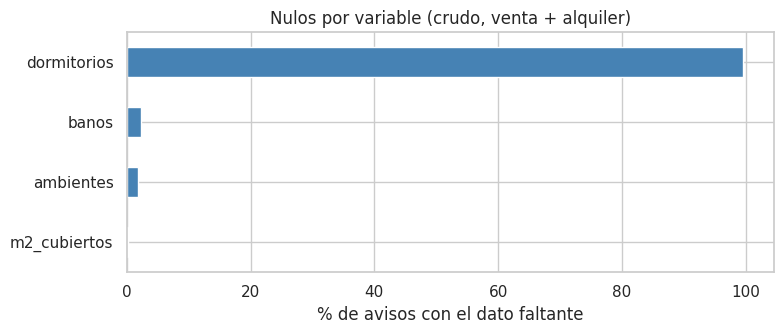

,m2_cubiertos,dormitorios,banos,ambientes
operacion,,,,
alquiler,0.4,99.3,2.0,3.4
venta,0.1,99.6,2.4,1.4


In [4]:
pct_nulos = (crudo.isna().mean() * 100).sort_values()
pct_nulos = pct_nulos[pct_nulos > 0]

fig, ax = plt.subplots(figsize=(8, 3.5))
pct_nulos.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% de avisos con el dato faltante")
ax.set_title("Nulos por variable (crudo, venta + alquiler)")
plt.tight_layout()
plt.show()

cols = ["m2_cubiertos", "dormitorios", "banos", "ambientes"]
(crudo.groupby("operacion")[cols].apply(lambda d: d.isna().mean() * 100)).round(1)

`dormitorios` está vacía en cerca del 99% de los avisos, tanto en venta como en alquiler. No se puede usar ni imputar, porque imputar el 99% sería inventar la variable. La descartamos del dataset procesado y lo dejamos documentado.

`ambientes` (3.4% en alquiler y 1.4% en venta), `banos` (2.0% y 2.4%) y `m2_cubiertos` (0.4% o menos) tienen pocos faltantes y son las que vamos a tratar. El resto de las variables (precio, moneda, dirección, barrio, tipo) no tiene nulos.

### 2.2 Mecanismo de ausencia
Antes de imputar hay que preguntarse si los faltantes son al azar o dependen de otra variable.

In [5]:
print("% de faltantes según operación y tipo de propiedad")
tabla = pd.concat({
    c: crudo.groupby(["operacion", "tipo_propiedad"])[c].apply(lambda s: s.isna().mean() * 100)
    for c in ["ambientes", "banos", "m2_cubiertos"]
}, axis=1).round(1)
display(tabla)

print("Test chi-cuadrado: ¿la ausencia depende del tipo de propiedad?")
for var in ["ambientes", "banos", "m2_cubiertos"]:
    contingencia = pd.crosstab(crudo[var].isna(), crudo["tipo_propiedad"])
    chi2, p, *_ = stats.chi2_contingency(contingencia)
    print(f"  {var:13s} chi2 = {chi2:7.1f}   p = {p:.2e}")

% de faltantes según operación y tipo de propiedad


ambientes  banos  m2_cubiertos
operacion tipo_propiedad                                
alquiler  casa                 12.7    4.5           0.4
          departamento          3.2    1.9           0.4
          ph                    2.5    2.3           0.7
venta     casa                  4.6    7.1           0.5
          departamento          1.3    2.2           0.1
          ph                    1.1    2.3           0.1

Test chi-cuadrado: ¿la ausencia depende del tipo de propiedad?
  ambientes     chi2 =   186.6   p = 3.09e-41
  banos         chi2 =   177.6   p = 2.73e-39


  m2_cubiertos  chi2 =    14.9   p = 5.86e-04


En `ambientes` y `banos` la ausencia no es al azar: depende del tipo de propiedad. Las casas en alquiler no informan `ambientes` en el 12.7% de los casos, contra el 3.2% de los departamentos, y en venta las casas no informan `banos` en el 7.1% contra el 2.2%. Es un faltante que depende de una variable que sí observamos (tipo MAR), así que imputar con la media global sesgaría y la imputación tiene que ser condicional al tipo de propiedad.

En `m2_cubiertos` la dependencia también es significativa (p < 0.001), pero las diferencias son mínimas (entre 0.1% y 0.7%) y falta tan poco que no vale la pena imputarlo.

### 2.3 Duplicados
Mirar el `id_aviso` no alcanza: un mismo inmueble puede republicarse con otro código. Por eso medimos los duplicados también por contenido.

In [6]:
print("IDs duplicados:", crudo["id_aviso"].duplicated().sum())

dup = lp.marcar_duplicados(crudo)
tabla = dup.groupby(["operacion", "es_emprendimiento"]).agg(
    avisos=("id_aviso", "size"),
    dup_posible=("dup_posible", "sum"),
    dup_eliminable=("dup_eliminable", "sum"),
)
tabla["% posible"] = (tabla["dup_posible"] / tabla["avisos"] * 100).round(1)
tabla

IDs duplicados: 1


avisos  dup_posible  dup_eliminable  % posible
operacion es_emprendimiento                                                
alquiler  0                   10166          377             292        3.7
venta     0                   24922          913             649        3.7
          1                   20646         1398               0        6.8

Por ID no hay duplicados, pero por contenido (misma operación, dirección, precio, moneda, m² y ambientes) aparecen 2.688 avisos repetidos, el 4.8%. En venta nueva, buena parte de los 1.398 repetidos probablemente sean unidades idénticas dentro de un mismo emprendimiento, y eso no son duplicados de verdad.

Por eso trabajamos con dos niveles. `dup_posible` (2.688) solo se marca y se conserva. `dup_eliminable` (941) exige además que coincida el título y que el aviso no sea un emprendimiento, y es el único grupo que eliminamos. En la sección 4 comprobamos que esta decisión casi no cambia los resultados.

### 2.4 Cardinalidad y consistencia de categorías
La unidad geográfica del proyecto son los 48 barrios oficiales de CABA, así que verificamos que el campo `barrio` sea consistente.

In [7]:
nombres_oficiales = {lp.normalizar_texto(b) for b in lp.BARRIOS_OFICIALES}
coincide = crudo["barrio"].map(lp.normalizar_texto).isin(nombres_oficiales)

print(f"Valores distintos en 'barrio': {crudo['barrio'].nunique()} (esperados: 48)")
print(f"Avisos cuyo barrio coincide con un barrio oficial tal cual: {coincide.mean() * 100:.1f}%")
print("\nValores que NO coinciden (los más frecuentes):")
display(crudo.loc[~coincide, "barrio"].value_counts().head(12).to_frame("avisos"))

print("ciudad:", crudo["ciudad"].value_counts().to_dict())
print("tipo_propiedad:", crudo["tipo_propiedad"].value_counts().to_dict())

Valores distintos en 'barrio': 181 (esperados: 48)
Avisos cuyo barrio coincide con un barrio oficial tal cual: 97.9%

Valores que NO coinciden (los más frecuentes):


,avisos
barrio,
Paternal,399
Villa Gral. Mitre,234
Santa Rita,145
Belgrano R,58
Palermo Soho,41
Palermo Hollywood,34
Palermo Chico,18
Barrio Norte,17
Belgrano Chico,16


ciudad: {'Capital Federal': 55729, 'Recoleta': 1, 'Santa Fe': 1, 'Bs.As. Costa Atlántica': 1, 'Bs.As. G.B.A. Oeste': 1, 'Bs.As. G.B.A. Norte': 1}
tipo_propiedad: {'departamento': 51444, 'ph': 2317, 'casa': 1973}


`barrio` tiene **181 valores distintos en lugar de 48**. Las causas, de mayor a menor peso:
1. Otro nombre para el mismo barrio (unos 780 avisos): MercadoLibre escribe `Paternal` (oficial: La Paternal), `Villa Gral. Mitre` y `Santa Rita` (oficial: Villa Santa Rita).
2. Sub-barrios como `Belgrano R`, `Palermo Soho`, `Palermo Hollywood` o `Las Cañitas`, que pertenecen sin ambigüedad a Belgrano o Palermo (y `Once` a Balvanera). Los agrupamos en el barrio oficial.
3. Calles cargadas como barrio (unos 150 avisos). El parseo del scraper tomó mal el campo y la dirección no trae el barrio, así que no se puede recuperar.
4. Zonas que no son un único barrio: `Barrio Norte`, `Congreso` y `Parque Centenario` atraviesan varios barrios. No las asignamos a ninguno para no inventar.

Además hay avisos con `ciudad` distinta de "Capital Federal" (Rosario, Mar de Ajó, Morón, General San Martín), que están fuera del alcance del proyecto.

### 2.5 Unidades, monedas y escalas
Si `precio` no está en una única unidad, ningún promedio tiene sentido. Lo comprobamos.

avisos   minimo     mediana     maximo
operacion moneda                                        
alquiler  ARS       7525    18000    780000.0  111111111
          USD       2641       10      1400.0     450000
venta     ARS          5  1500000  99000000.0  174988000
          USD      45563      600    143959.0   12000000

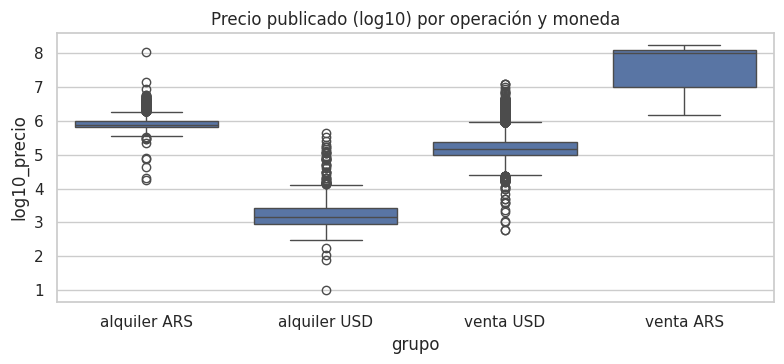

In [8]:
escala = crudo.groupby(["operacion", "moneda"])["precio"].agg(
    avisos="size", minimo="min", mediana="median", maximo="max"
)
display(escala)

crudo_plot = crudo.assign(log10_precio=np.log10(crudo["precio"]), grupo=crudo["operacion"] + " " + crudo["moneda"])
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.boxplot(data=crudo_plot, x="grupo", y="log10_precio", ax=ax)
ax.set_title("Precio publicado (log10) por operación y moneda")
plt.tight_layout()
plt.show()

El alquiler mezcla dos monedas en la misma columna: 7.525 avisos en pesos (mediana de unos $780.000) y 2.641 en dólares (mediana de unos US$1.400). Cualquier promedio o histograma de `precio` sin separar por moneda es engañoso. Para compararlos hace falta una cotización con fuente y fecha (parámetro `TIPO_CAMBIO`); hasta que se defina, `precio_usd` queda vacío en las filas en pesos.

La venta está en dólares (45.563 de 45.568). Los 5 avisos en pesos se marcan, no se convierten.

El mínimo y el máximo ya adelantan otro problema: precios como 10 o 111.111.111 no son verosímiles (sección 2.7).

### 2.6 Coherencia entre variables relacionadas
Buscamos combinaciones físicamente imposibles, como un departamento de 40 m² con 20 ambientes. Los umbrales salen del sentido común: un ambiente de menos de 8 m², o un baño por menos de 8 m², no existe.

In [9]:
reglas = {
    "m² cubiertos < 10": (crudo["m2_cubiertos"] < 10).sum(),
    "m² cubiertos > 500": (crudo["m2_cubiertos"] > 500).sum(),
    "ambientes > 10": (crudo["ambientes"] > 10).sum(),
    "m²/ambiente < 8": ((crudo["m2_cubiertos"] / crudo["ambientes"]) < 8).sum(),
    "baños > 8": (crudo["banos"] > 8).sum(),
    "m²/baño < 8": ((crudo["m2_cubiertos"] / crudo["banos"]) < 8).sum(),
    "precio con 5+ dígitos iguales (placeholder)": lp.marcar_precios_atipicos(crudo)["precio_placeholder"].sum(),
    "título con tipología no residencial (oficina, hotel, galpón...)": lp.marcar_no_residencial(crudo)["posible_no_residencial"].sum(),
}
display(pd.Series(reglas, name="avisos").to_frame())

crudo.loc[crudo["ambientes"] > 15, ["titulo", "m2_cubiertos", "ambientes"]].head(6)

,avisos
m² cubiertos < 10,109
m² cubiertos > 500,132
ambientes > 10,92
m²/ambiente < 8,122
baños > 8,44
m²/baño < 8,110
precio con 5+ dígitos iguales (placeholder),27
"título con tipología no residencial (oficina, hotel, galpón...)",397


,titulo,m2_cubiertos,ambientes
0,Departamento En Alquiler En Floresta,40.0,20.0
4428,"Alquiler Semipiso 3 Amb Con Cochera, Balcón Y ...",66.0,33.0
8735,"Monoambiente En Planta Baja, Cómodo Y Funciona...",33.0,71.0
9968,Alquiler De Hotel Ambientado Y Decorado De Épo...,850.0,24.0
9975,"Oficina En Belgrano, 17 Ambientes En Edificio ...",554.0,17.0
10022,Exclusiva Casa De 26 Ambientes En Monserrat Co...,1.1,26.0


Aparecen ambientes de 20, 33 y hasta 71 en avisos de 33 a 66 m², y baños de 76 o 43. En esos casos el título suele decir lo correcto ("Monoambiente", "3 Amb") y el campo cargado quedó roto, o sea que es un error de captura.

Pero no todo valor extremo es un error. Entre los avisos con más de 15 ambientes hay un hotel (24 ambientes, 850 m²), una oficina (17 ambientes, 554 m²) y un block de 12 departamentos (30 ambientes, 400 m²), todos coherentes con su superficie. Por eso la regla de corrección no usa topes del tipo "más de 15 ambientes", sino coherencia física.

Otros 109 avisos tienen menos de 10 m², que no puede ser una vivienda, y en varios el título menciona metros razonables ("44,5 M2" quedó cargado como 1). Los m² mayores a 500 (132 avisos) los conservamos: existen casas, PH y emprendimientos grandes.

Mirando estos ejemplos aparece además un problema de alcance: hay avisos de tipología no residencial dentro de las categorías (oficinas, hoteles, galpones, consultorios, terrenos). Con una regla conservadora sobre el título se detectan 397 (0,7%). Los marcamos con `posible_no_residencial` y dejamos para el EDA la decisión de excluirlos.

### 2.7 Valores atípicos de precio
Queremos distinguir precios verosímiles de errores sin eliminar nada. Como conviven varias escalas, el atípico se define dentro de cada combinación operación × moneda, con un z robusto (mediana y MAD) sobre `log10(precio)`.

In [10]:
con_marcas = lp.marcar_precios_atipicos(crudo, z_umbral=Z_ATIPICO)
resumen = con_marcas.groupby(["operacion", "moneda"]).agg(
    avisos=("id_aviso", "size"),
    atipicos=("precio_atipico", "sum"),
    placeholders=("precio_placeholder", "sum"),
)
resumen["% inválidos"] = ((resumen["atipicos"] + resumen["placeholders"]) / resumen["avisos"] * 100).round(2)
display(resumen)

con_marcas.loc[con_marcas["precio_placeholder"], ["operacion", "moneda", "precio", "titulo"]].head(6)

avisos  atipicos  placeholders  % inválidos
operacion moneda                                             
alquiler  ARS       7525        61             4         0.86
          USD       2641        26             0         0.98
venta     ARS          5         1             0        20.00
          USD      45563       222            23         0.54

,operacion,moneda,precio,titulo
3555,alquiler,ARS,999999,Moderno Depto 2 Ambientes Amoblado Con Amenities
4274,alquiler,ARS,111111111,Departamento Puerto Madero Monoambiente
7204,alquiler,ARS,77777,Departamento En Alquiler De Dos Ambientes En C...
8676,alquiler,ARS,999999,Alquiler Departamento 3 Ambientes Parque Chas
22363,venta,USD,99999,Oportunidad 5 Amb + Dep. 3 Baños A Refaccionar
26850,venta,USD,11111,*** R E S E R V A D O *** Semipiso De Categorí...


En los tres grupos grandes queda marcado entre 0.5% y 1% de los avisos (venta en pesos tiene solo 5 avisos y uno queda marcado). Mirando los casos hay de dos tipos: placeholders (111111111, 999999, 99999, 11111…) y precios de una magnitud incompatible con su grupo (alquileres de US$10, ventas de US$600).

Los marcamos (`precio_atipico`, `precio_placeholder`, `precio_valido`) pero no los eliminamos. La fila sigue existiendo y el EDA decide si la excluye de una estadística de precio. Un precio muy alto en una casa de lujo puede ser genuino, por eso el criterio es relativo al grupo.

### 2.8 Cobertura geográfica y sesgos de captura
¿Los datos cubren todo el universo o quedaron recortados por cómo se scrapeó?

In [11]:
por_barrio = lp.resolver_barrio(crudo).groupby(["barrio", "operacion"]).size().unstack(fill_value=0)
print("Barrios oficiales presentes:", por_barrio.shape[0], "de 48")
print("Fecha de publicación disponible:", any("fecha" in c for c in crudo.columns))

top = por_barrio.sort_values("venta", ascending=False).head(10)
display(top)
print(f"Barrios con 2.000 avisos o más en venta: {(por_barrio['venta'] >= 2000).sum()}")
print(f"Barrios con 2.000 avisos o más en alquiler: {(por_barrio['alquiler'] >= 2000).sum()}")
print(f"\n% de emprendimientos en venta: {crudo.loc[crudo['operacion'] == 'venta', 'es_emprendimiento'].mean() * 100:.1f}%")

Barrios oficiales presentes: 48 de 48
Fecha de publicación disponible: False


operacion,alquiler,venta
barrio,,
Villa Urquiza,500,2320
Palermo,1139,2283
Belgrano,851,2269
Caballito,762,2266
Almagro,418,2192
Villa Crespo,298,2154
Recoleta,924,2140
Núñez,416,2058
Flores,356,1811


Barrios con 2.000 avisos o más en venta: 8
Barrios con 2.000 avisos o más en alquiler: 0

% de emprendimientos en venta: 45.3%


Están los 48 barrios, pero no hay ninguna fecha (ni de publicación ni de extracción dentro del archivo). Eso impide hacer análisis temporal o medir tiempo en el mercado, y deja fuera de alcance cualquier hipótesis sobre evolución o valorización futura.

En venta aparece un posible tope de captura. Los barrios más grandes (Villa Urquiza, Palermo, Belgrano, Caballito, Almagro, Villa Crespo, Recoleta y Núñez) quedan todos entre unos 2.050 y 2.320 avisos, aunque su inventario real es muy distinto (al revisar el sitio, Palermo tenía más de 5.800 avisos de venta publicados). Parece la huella de un máximo de resultados por búsqueda de la plataforma, pero es una hipótesis que hay que confirmar con quien scrapeó venta. Si es cierta, tiene dos consecuencias: la cantidad de avisos por barrio no es comparable entre barrios grandes y chicos (no sirve para medir densidad ni oferta), y dentro de un barrio grande la muestra es lo que la plataforma ordena primero, no una muestra aleatoria. El alquiler no muestra este problema: ningún barrio supera los ~1.150 avisos.

Como sesgos de la fuente hay que declarar que es un solo portal, que son precios de oferta y no de cierre, y que el 45% de la venta son emprendimientos.

### 2.9 Fuente adicional: Argenprop
Vemos si conviene sumar Argenprop al dataset maestro.

In [12]:
argenprop, _ = lp.leer_raw("argenprop_departamentos_caba.csv", RAW_DIR)
print(f"Argenprop: {argenprop.shape[0]:,} avisos x {argenprop.shape[1]} columnas")
print("Columnas:", list(argenprop.columns))
lp.resumen_calidad(argenprop)[["tipo", "pct_nulos"]].T

Argenprop: 1,000 avisos x 14 columnas
Columnas: ['titulo', 'direccion', 'barrio', 'ciudad', 'moneda', 'precio', 'expensas', 'm2_cubiertos', 'dormitorios', 'banos', 'ambientes', 'antiguedad', 'link', 'pagina']


,titulo,direccion,barrio,ciudad,moneda,precio,expensas,m2_cubiertos,dormitorios,banos,ambientes,antiguedad,link,pagina
tipo,str,str,str,str,str,float64,float64,float64,float64,float64,float64,str,float64,int64
pct_nulos,0.0,0.0,0.0,0.0,0.0,0.1,9.8,15.7,26.9,56.1,85.4,30.6,100.0,0.0


Decidimos no integrarlo. Tiene solo 1.000 avisos (todos de alquiler), no trae identificador ni link (100% vacío, así que no se pueden detectar superposiciones con MercadoLibre) y está muy incompleto: `ambientes` falta en el 85%, `banos` en el 56%, `antiguedad` en el 31% y `m2_cubiertos` en el 16%. Imputar esa proporción no sería defendible. Además su estructura es distinta (trae `expensas` y `antiguedad`). Queda en `/data/raw` como fuente de contraste.

## 3. Limpieza y preprocesamiento inicial
Para cada paso decimos qué hacemos, por qué y a cuántos registros afecta. El orden importa: primero resolvemos alcance y duplicados (que cambian el universo), después corregimos valores imposibles y recién al final imputamos. Todos los cambios se van acumulando en `LOG`.

### 3.1 Normalización de barrio y link
El barrio es la unidad geográfica del proyecto y hoy tiene 181 valores. El link trae parámetros de tracking que solo ocupan espacio. Conservamos el barrio original en `barrio_original`.

In [13]:
df = lp.resolver_barrio(crudo, LOG)
df = lp.limpiar_link(df)

print("Cómo se resolvió el barrio:")
display(df["barrio_via"].value_counts().to_frame("avisos"))
print("Barrios distintos tras la normalización:", df["barrio"].nunique())

Cómo se resolvió el barrio:


,avisos
barrio_via,
directo,55558
no_resuelto,149
ambiguo,26
desde_direccion,1


Barrios distintos tras la normalización: 48


Después de normalizar quedan exactamente 48 barrios. 55.558 avisos se resolvieron directo (nombre oficial, alias o sub-barrio), 149 no tienen barrio identificable (solo traían la calle), 26 pertenecen a zonas ambiguas y 1 se recuperó desde la dirección. Los 175 sin barrio quedan con `barrio` vacío: siguen en el dataset para los análisis que no dependen del barrio, pero no entran en comparaciones por barrio.

### 3.2 Alcance y duplicados
Los avisos de fuera de CABA no pertenecen al universo del proyecto. De los duplicados eliminamos solo los de alta confianza que definimos en 2.3 (alquiler y venta usada con mismo contenido y mismo título); los posibles duplicados restantes quedan marcados. La tipología posiblemente no residencial (2.6) también se marca sin eliminar.

In [14]:
df = lp.marcar_fuera_de_alcance(df, LOG)
df = lp.marcar_no_residencial(df, LOG)
df = lp.marcar_duplicados(df, LOG)

antes = len(df)
print("Fuera de CABA:", df["fuera_de_alcance"].sum(), "|  duplicados eliminables:", df["dup_eliminable"].sum())
df = df[~df["fuera_de_alcance"] & ~df["dup_eliminable"]].copy()
print(f"Filas: {antes:,} -> {len(df):,}  (se eliminan {antes - len(df):,})")
print("Duplicados posibles que se conservan marcados:", df["dup_posible"].sum())
print("Avisos marcados como posible tipología no residencial (se conservan):", df["posible_no_residencial"].sum())

Fuera de CABA: 4 |  duplicados eliminables: 941
Filas: 55,734 -> 54,789  (se eliminan 945)
Duplicados posibles que se conservan marcados: 1747
Avisos marcados como posible tipología no residencial (se conservan): 391


### 3.3 Valores imposibles a faltante
Los ambientes, baños y m² imposibles de la sección 2.6 son errores de captura. Los pasamos a `NaN` (con una marca por variable) para que reciban el mismo tratamiento que cualquier faltante; no eliminamos filas. Evaluamos primero el m² y después ambientes y baños con el m² ya corregido, porque si el dato roto es el m² no hay que culpar a los ambientes.

In [15]:
df = lp.corregir_valores_imposibles(df, LOG)
df[["m2_fuera_rango", "ambientes_fuera_rango", "banos_fuera_rango"]].sum().to_frame("avisos corregidos")

,avisos corregidos
m2_fuera_rango,107
ambientes_fuera_rango,27
banos_fuera_rango,16


Se corrigen 107 m², 27 ambientes y 16 baños (sobre el universo ya sin duplicados). Son pocos y no cambian el tamaño del dataset. Los valores extremos pero coherentes con su superficie (hoteles, edificios en block) se conservan.

### 3.4 Precios atípicos
Mismo criterio que en 2.7: se marcan, no se eliminan. `precio_valido` es lo que tiene que usar cualquier estadística de precio.

In [16]:
df = lp.marcar_precios_atipicos(df, z_umbral=Z_ATIPICO, log=LOG)
print("Precios marcados como no válidos:", (~df["precio_valido"]).sum(),
      f"({(~df['precio_valido']).mean() * 100:.2f}% del dataset)")

Precios marcados como no válidos: 321 (0.59% del dataset)


### 3.5 Partición train / test (antes de imputar)
La hipótesis H1 reformulada pide validar un modelo fuera de muestra. Si las tablas de imputación (medianas y modas) se calcularan con toda la base, el test quedaría contaminado con información propia (fuga de datos). Por eso la partición se hace acá, con semilla fija, y se guarda en la columna `split` para que todos los notebooks siguientes usen la misma. Está estratificada por operación.

In [17]:
df = lp.asignar_split(df, semilla=SEMILLA, frac_test=FRAC_TEST)
pd.crosstab(df["operacion"], df["split"], margins=True)

split,test,train,All
operacion,,,
alquiler,1975,7899,9874
venta,8983,35932,44915
All,10958,43831,54789


### 3.6 Ambientes: primero recuperar, después imputar
En 2.6 vimos que el título suele traer el dato correcto. Leerlo del texto es mejor que estimarlo, porque es información real del aviso y no depende de supuestos estadísticos. Pero antes de usar esa regla hay que validarla.

In [18]:
acierto, n = lp.validar_regla_titulo(df)
print(f"La regla del título coincide con el dato cargado en {acierto * 100:.1f}% de {n:,} avisos que tienen ambos")

df = lp.recuperar_ambientes_titulo(df, LOG)
df["ambientes_origen"].value_counts().to_frame("avisos")

La regla del título coincide con el dato cargado en 96.1% de 36,135 avisos que tienen ambos


,avisos
ambientes_origen,
cargado,53799
titulo,615
faltante,375


La regla acierta en el 96.1% de 36.135 avisos comparables y recupera 615 ambientes. Quedan 375 sin dato, que pasan a la imputación estadística.

### 3.7 Imputación de ambientes y baños
- **Ambientes:** mediana por operación × tipo de propiedad × tramo de m². Es condicional al tipo (la ausencia depende de él, sección 2.2) y al tamaño (más m², más ambientes). Si el m² también falta, se cae al nivel operación × tipo y después al global.
- **Baños:** moda por tipo × ambientes. Es un conteo chico y la moda respeta su naturaleza discreta.
- **m² no se imputa.** Es el denominador del precio por m² y la variable explicativa central del modelo de H1; imputarlo fabricaría el denominador.
- **`dormitorios` se descarta** (99% vacía).

Las tablas se calculan solo con `train` y se aplican a todo el dataset. Cada valor imputado queda marcado (`ambientes_origen`, `banos_imputado`).

Antes de imputar de verdad ponemos a prueba el método: ocultamos una parte de los valores conocidos del test, los imputamos con las tablas del train y comparamos contra un baseline global (siempre la misma mediana o moda).

In [19]:
train = df[df["split"] == "train"]
test = df[df["split"] == "test"]
imputador = lp.ajustar_imputador(train)

print("Ambientes: método propuesto vs baseline global (valores conocidos del test, ocultados)")
display(lp.evaluar_imputacion(test, imputador, "ambientes"))
print("Baños:")
display(lp.evaluar_imputacion(test, imputador, "banos"))

Ambientes: método propuesto vs baseline global (valores conocidos del test, ocultados)


,metodo,exactitud,error_abs_medio
0,grupo (propuesto),0.596,0.459
1,baseline global,0.301,1.041


Baños:


,metodo,exactitud,error_abs_medio
0,grupo (propuesto),0.756,0.284
1,baseline global,0.702,0.418


**Ambientes:** el método por grupo acierta el valor exacto en el 59.6% de los casos contra el 30.1% del baseline, y se equivoca en promedio 0.46 ambientes contra 1.04. Mejora claramente el baseline, pero no es perfecto: 4 de cada 10 imputaciones no coinciden. Por eso cada valor imputado queda marcado y el análisis puede excluirlos si hace falta.

**Baños:** la mejora es más modesta (75.6% contra 70.2% de exactitud), porque casi todos los inmuebles tienen un solo baño y el baseline ya acierta mucho. Igual, el método por grupo no empeora y es coherente con el mecanismo de ausencia.

Nos parece defendible imputar porque el método se midió, le gana al baseline y los valores imputados se pueden aislar.

In [20]:
df = lp.imputar(df, imputador, LOG)

print("Nulos después de imputar:")
df[["ambientes", "banos", "m2_cubiertos"]].isna().sum().to_frame("nulos")

Nulos después de imputar:


,nulos
ambientes,0
banos,0
m2_cubiertos,196


Después de imputar quedan 0 nulos en `ambientes` y `banos`, y 196 en `m2_cubiertos`. Esto último es a propósito: ese dato no se inventa, esos avisos simplemente no entran al cálculo de precio por m².

### 3.8 Moneda y variables derivadas básicas
La consigna pide que toda normalización monetaria indique fuente, tipo de cambio y fecha. Se **trae de la API pública de bluelytics** el **dólar blue (venta)** para una **fecha fija** (`FECHA_TIPO_CAMBIO`), de modo que el resultado sea reproducible: el valor histórico de una fecha pasada no cambia aunque la notebook se ejecute otro día. Si la API no responde, se usa un valor de respaldo documentado (`TC_BLUE_RESPALDO`). Se usa el blue —y no el oficial— porque las operaciones inmobiliarias en Argentina se liquidan en dólar billete.

Los avisos en USD no se modifican; los avisos en pesos (principalmente alquiler) se convierten con esa cotización. `precio_m2` se calcula como `precio_usd / m2_cubiertos`, **en dólares**, para que sea comparable entre barrios y operaciones.

In [ ]:
# --- Tipo de cambio: se trae de la API de bluelytics para una fecha FIJA (reproducible).
#     Si la API falla o no hay dato para esa fecha, se usa el valor de respaldo (hardcodeado). ---
def obtener_tipo_cambio(fecha, valor_respaldo, tipo="blue"):
    """
    Dólar blue (venta) de la fecha indicada, desde la API pública de bluelytics.
    Reproducible: el valor histórico de una fecha pasada no cambia. Toma la última
    cotización disponible en o antes de `fecha` (robusto ante fines de semana/feriados).
    Si la API no responde o cambia su formato, devuelve `valor_respaldo`.
    """
    base = {"tipo": tipo, "fecha": fecha}
    try:
        ev = pd.read_json("https://api.bluelytics.com.ar/v2/evolution.json")
        ev["date"] = pd.to_datetime(ev["date"]).dt.strftime("%Y-%m-%d")
        blue = ev[(ev["source"].str.lower() == tipo) & (ev["date"] <= fecha)].sort_values("date")
        if len(blue):
            fila = blue.iloc[-1]
            return {**base, "valor": float(fila["value_sell"]), "fecha": str(fila["date"]),
                    "fuente": "bluelytics.com.ar (API, evolution.json)", "origen": "api"}
    except Exception as e:
        print(f"  [aviso] no se pudo consultar bluelytics ({e}); se usa el valor de respaldo.")
    return {**base, "valor": float(valor_respaldo),
            "fuente": "bluelytics.com.ar / relevamiento (respaldo)", "origen": "respaldo"}

TIPO_CAMBIO = obtener_tipo_cambio(FECHA_TIPO_CAMBIO, TC_BLUE_RESPALDO)
print(f"Tipo de cambio [{TIPO_CAMBIO['origen']}]: ${TIPO_CAMBIO['valor']:.0f} por USD "
      f"({TIPO_CAMBIO['tipo']}, {TIPO_CAMBIO['fecha']}) - {TIPO_CAMBIO['fuente']}")

df = lp.agregar_precio_usd(df, TIPO_CAMBIO)

# precio_m2 EN USD (homogéneo y comparable entre barrios y operaciones): precio_usd / m2,
# solo con precio válido, m2 disponible y precio_usd disponible (no se imputa el denominador).
ok_m2 = df["precio_valido"] & df["m2_cubiertos"].notna() & df["precio_usd"].notna()
df["precio_m2"] = np.where(ok_m2, df["precio_usd"] / df["m2_cubiertos"], np.nan)

df.groupby(["operacion", "moneda"]).agg(
    avisos=("id_aviso", "size"),
    precio_usd_ok=("precio_usd", lambda s: s.notna().sum()),
    precio_m2_usd_mediana=("precio_m2", "median"),
).round(0)

### 3.9 Tipos finales y columnas descartadas
`ambientes` y `banos` son conteos, así que pasan a enteros. Descartamos `dormitorios` (99% vacía), `fuente` y las marcas que quedaron constantes después de filtrar (`fuera_de_alcance` y `dup_eliminable`).

In [22]:
df["ambientes"] = df["ambientes"].round().astype("Int64")
df["banos"] = df["banos"].round().astype("Int64")

COLUMNAS_FINALES = [
    "id_aviso", "operacion", "tipo_propiedad", "es_emprendimiento",
    "barrio", "barrio_original", "barrio_via", "ciudad", "direccion", "titulo",
    "moneda", "precio", "precio_usd", "precio_valido", "precio_m2",
    "m2_cubiertos", "ambientes", "ambientes_origen", "banos", "banos_imputado",
    "dup_posible", "posible_no_residencial", "m2_fuera_rango", "ambientes_fuera_rango", "banos_fuera_rango",
    "precio_atipico", "precio_placeholder", "split", "link",
]
limpio = df[COLUMNAS_FINALES].reset_index(drop=True)
print("Dataset procesado:", limpio.shape)
limpio.dtypes.to_frame("tipo").T

Dataset procesado: (54789, 29)


,id_aviso,operacion,tipo_propiedad,es_emprendimiento,barrio,barrio_original,barrio_via,ciudad,direccion,titulo,moneda,precio,precio_usd,precio_valido,precio_m2,m2_cubiertos,ambientes,ambientes_origen,banos,banos_imputado,dup_posible,posible_no_residencial,m2_fuera_rango,ambientes_fuera_rango,banos_fuera_rango,precio_atipico,precio_placeholder,split,link
tipo,str,str,str,int64,str,str,str,str,str,str,str,int64,float64,bool,float64,float64,Int64,str,Int64,bool,bool,bool,bool,bool,bool,bool,bool,str,object


## 4. Comparación entre el dato crudo y el procesado
Mostramos qué cambió y comprobamos que las decisiones (en especial eliminar duplicados) no modifican las conclusiones de forma relevante. Para eso comparamos la mediana de precio por m² por barrio en venta (USD, avisos válidos con m²).

In [23]:
resumen = pd.DataFrame({
    "crudo": {
        "avisos": len(crudo),
        "barrios distintos": crudo["barrio"].nunique(),
        "nulos ambientes": crudo["ambientes"].isna().sum(),
        "nulos banos": crudo["banos"].isna().sum(),
        "nulos m2_cubiertos": crudo["m2_cubiertos"].isna().sum(),
    },
    "procesado": {
        "avisos": len(limpio),
        "barrios distintos": limpio["barrio"].nunique(),
        "nulos ambientes": limpio["ambientes"].isna().sum(),
        "nulos banos": limpio["banos"].isna().sum(),
        "nulos m2_cubiertos": limpio["m2_cubiertos"].isna().sum(),
    },
})
display(resumen)

# Sensibilidad: mediana de USD/m² por barrio en venta, con el dato crudo vs con el procesado
venta_cruda = crudo[(crudo["operacion"] == "venta") & (crudo["moneda"] == "USD") & (crudo["m2_cubiertos"] >= 10)].copy()
venta_cruda["precio_m2"] = venta_cruda["precio"] / venta_cruda["m2_cubiertos"]
venta_cruda["barrio"] = lp.resolver_barrio(venta_cruda)["barrio"]

med_cruda = venta_cruda.groupby("barrio")["precio_m2"].median()
med_limpia = limpio[(limpio["operacion"] == "venta") & (limpio["moneda"] == "USD")].groupby("barrio")["precio_m2"].median()
cmp = pd.DataFrame({"crudo": med_cruda, "procesado": med_limpia}).dropna()
cmp["diferencia %"] = ((cmp["procesado"] / cmp["crudo"] - 1) * 100).round(2)

print(f"USD/m² mediana por barrio (venta): diferencia absoluta mediana = {cmp['diferencia %'].abs().median():.2f}%, "
      f"máxima = {cmp['diferencia %'].abs().max():.2f}%")
cmp.reindex(cmp["diferencia %"].abs().sort_values(ascending=False).index).head(5)

,crudo,procesado
avisos,55734,54789
barrios distintos,181,48
nulos ambientes,983,0
nulos banos,1290,0
nulos m2_cubiertos,91,196


USD/m² mediana por barrio (venta): diferencia absoluta mediana = 0.12%, máxima = 2.43%


,crudo,procesado,diferencia %
barrio,,,
Puerto Madero,6153.846154,6004.166667,-2.43
Villa Soldati,977.011494,956.521739,-2.10
Parque Avellaneda,1528.958944,1542.257085,0.87
Parque Patricios,1831.250000,1846.153846,0.81
Boedo,2205.882353,2220.388889,0.66


El procesado tiene 945 avisos menos que el crudo (4 fuera de CABA y 941 duplicados), `barrio` pasa de 181 a 48 valores, y los nulos de `ambientes` y `banos` desaparecen porque se recuperaron o imputaron (con marca de origen). Los nulos de `m2_cubiertos` suben de 91 a 196: los 107 m² imposibles se convirtieron en faltantes y, a propósito, no se imputan.

La sensibilidad muestra que limpiar casi no mueve las medianas de USD/m² por barrio: la diferencia mediana entre barrios es de 0.12% y la máxima de 2.43% (Puerto Madero). Las decisiones de limpieza no cambian el panorama; lo que hacen es dejar un dato coherente y que se puede seguir paso a paso.

## 5. Registro de cambios y archivos generados
Guardamos el dataset procesado, el registro de cada regla aplicada y un diccionario de datos. El dato crudo en `/data/raw` no se modifica.

In [24]:
log = pd.DataFrame(LOG)
display(log)

limpio.to_csv(PROCESSED_DIR / "propiedades_ml_limpio.csv", index=False, encoding="utf-8-sig")
log.to_csv(PROCESSED_DIR / "log_limpieza.csv", index=False, encoding="utf-8-sig")
print("\nGuardado en:", (PROCESSED_DIR).relative_to(RAIZ))

,regla,columna,afectados,accion
0,Barrio a los 48 oficiales,barrio,2736,normalizado (alias y sub-barrios) o recuperado...
1,Fuera de CABA,ciudad/barrio,4,eliminado (fuera del alcance)
2,Posible tipología no residencial,titulo,397,marcado (se conserva; decidir en el EDA)
3,Duplicado por contenido,(varias),941,"eliminado (alquiler y usados, mismo título)"
4,m² imposible (<10),m2_cubiertos,107,pasado a NaN
5,Ambientes incoherentes,ambientes,27,pasado a NaN
6,Baños incoherentes,banos,16,pasado a NaN
7,Precio atípico o placeholder,precio,321,marcado (se conserva; se excluye de estadístic...
8,Ambientes desde el título,ambientes,615,recuperado (regla validada)
9,Ambientes imputados,ambientes,375,mediana por operación x tipo x tramo de m² (tr...



Guardado en: data/processed


In [ ]:
diccionario = pd.DataFrame([
    ("id_aviso", "Código del aviso en MercadoLibre (MLA...). Identificador único.", "texto", "-", "Scraping ML", "Ninguna"),
    ("operacion", "Operación del aviso: venta o alquiler.", "categórica", "-", "Scraping ML", "Asignada por archivo de origen"),
    ("tipo_propiedad", "Tipología: departamento, PH o casa.", "categórica", "-", "Scraping ML", "Ninguna"),
    ("es_emprendimiento", "1 si es obra nueva/emprendimiento. En alquiler no se relevó: se asume 0.", "dicotómica", "0/1", "Scraping ML", "Supuesto 0 en alquiler"),
    ("barrio", "Barrio oficial de CABA (48). Vacío si no se pudo resolver o es una zona ambigua.", "categórica", "-", "Scraping ML", "Normalizado a barrios oficiales (alias, sub-barrios, dirección)"),
    ("barrio_original", "Barrio tal como vino del scraping.", "texto", "-", "Scraping ML", "Ninguna"),
    ("barrio_via", "Cómo se resolvió el barrio: directo, desde_direccion, ambiguo, no_resuelto.", "categórica", "-", "Derivada", "Regla de resolver_barrio"),
    ("ciudad", "Ciudad según el aviso.", "categórica", "-", "Scraping ML", "Ninguna (los de fuera de CABA se eliminaron)"),
    ("direccion", "Ubicación textual del aviso.", "texto", "-", "Scraping ML", "Ninguna"),
    ("titulo", "Título del aviso.", "texto", "-", "Scraping ML", "Ninguna"),
    ("moneda", "Moneda del precio publicado: USD o ARS.", "categórica", "-", "Scraping ML", "Ninguna"),
    ("precio", "Precio publicado en la moneda del aviso (alquiler: mensual).", "numérica", "ARS o USD", "Scraping ML", "Ninguna; ver precio_valido"),
    ("precio_usd", "Precio en USD. Igual a precio si la moneda es USD; en ARS se convierte con el dólar blue.", "numérica", "USD", "Derivada", "Conversión ARS->USD con dólar blue (API bluelytics, fecha fija; respaldo si falla)"),
    ("precio_valido", "False si el precio es atípico (z robusto por operación x moneda) o placeholder.", "dicotómica", "True/False", "Derivada", "Marca; no elimina filas"),
    ("precio_m2", "precio_usd / m2_cubiertos, EN USD (comparable entre barrios y operaciones). Vacío si el precio no es válido, falta m² o falta precio_usd.", "numérica", "USD/m²", "Derivada", "Calculado sobre precio_usd (dólar blue)"),
    ("m2_cubiertos", "Superficie cubierta. Vacía si era imposible (<10) o faltaba.", "numérica", "m²", "Scraping ML", "<10 a NaN; no se imputa"),
    ("ambientes", "Cantidad de ambientes.", "ordinal (entero)", "ambientes", "Scraping ML / título", "Incoherentes a NaN; recuperado del título; imputado por grupo"),
    ("ambientes_origen", "Origen del dato: cargado, titulo o imputado.", "categórica", "-", "Derivada", "Trazabilidad de la imputación"),
    ("banos", "Cantidad de baños.", "ordinal (entero)", "baños", "Scraping ML", "Incoherentes a NaN; imputado por moda de grupo"),
    ("banos_imputado", "True si el dato de baños fue imputado.", "dicotómica", "True/False", "Derivada", "Trazabilidad de la imputación"),
    ("dup_posible", "True si repite operación, dirección, precio, moneda, m² y ambientes de otro aviso.", "dicotómica", "True/False", "Derivada", "Marca; se conserva (puede ser un emprendimiento)"),
    ("posible_no_residencial", "True si el título menciona tipología no residencial (oficina, hotel, galpón, consultorio, terreno...).", "dicotómica", "True/False", "Derivada", "Marca conservadora; no elimina filas"),
    ("m2_fuera_rango", "True si el m² original era imposible.", "dicotómica", "True/False", "Derivada", "Marca de corrección"),
    ("ambientes_fuera_rango", "True si los ambientes originales eran incoherentes.", "dicotómica", "True/False", "Derivada", "Marca de corrección"),
    ("banos_fuera_rango", "True si los baños originales eran incoherentes.", "dicotómica", "True/False", "Derivada", "Marca de corrección"),
    ("precio_atipico", "True si el z robusto de log10(precio) supera el umbral dentro de su grupo.", "dicotómica", "True/False", "Derivada", "Marca"),
    ("precio_placeholder", "True si el precio tiene 5+ dígitos iguales seguidos.", "dicotómica", "True/False", "Derivada", "Marca"),
    ("split", "Partición reproducible train/test (semilla fija, por operación).", "categórica", "-", "Derivada", "Definida antes de imputar"),
    ("link", "URL del aviso sin parámetros de tracking.", "texto", "-", "Scraping ML", "Se quita lo que sigue al '#'"),
], columns=["variable", "significado", "tipo", "unidad", "fuente", "transformaciones"])

faltantes = set(limpio.columns) - set(diccionario["variable"])
assert not faltantes, f"Variables sin documentar: {faltantes}"
diccionario.to_csv(PROCESSED_DIR / "diccionario_datos.csv", index=False, encoding="utf-8-sig")
print(f"Diccionario guardado: {len(diccionario)} variables documentadas")

## 6. Conclusiones de este notebook
**Problemas de calidad que encontramos**
1. `barrio` con 181 valores en vez de 48 (alias, sub-barrios y calles cargadas como barrio).
2. El alquiler mezcla pesos y dólares en `precio`; se homogeneizó a USD con el dólar blue traído de la API de bluelytics (fecha fija, con respaldo).
3. 941 avisos duplicados de alta confianza que el ID no detecta, y otros ~1.750 posibles que se conservan marcados porque buena parte probablemente son unidades idénticas de emprendimientos, que no son duplicados reales.
4. Valores imposibles de ambientes, baños y m², y precios placeholder.
5. `dormitorios` casi vacía; `ambientes` y `banos` con faltantes que dependen del tipo de propiedad.
6. Un posible tope de captura en venta en los barrios grandes, y ausencia total de fechas.
7. Avisos de tipología no residencial (oficinas, hoteles, galpones…) dentro de las categorías residenciales: 397 marcados.

**Qué decidimos**
Normalizamos el barrio a los 48 oficiales; eliminamos los duplicados de alta confianza y marcamos el resto; pasamos los imposibles a faltante con una marca; marcamos (sin eliminar) los precios atípicos y la tipología no residencial; recuperamos ambientes del título (regla validada al 96.1%) y después imputamos por grupo; imputamos baños por la moda del grupo; no imputamos m²; descartamos `dormitorios`; y fijamos la partición train/test antes de imputar.

**Limitaciones que pasan al EDA y al modelado**
- No hay fecha de corte declarada ni fechas por aviso: sin análisis temporal, y hablar de "precio actual" requiere documentar la extracción.
- La cantidad de avisos por barrio no mide la oferta real (tope de captura), así que no hay que usarla como "densidad".
- La conversión ARS→USD usa una única cotización (dólar blue de una fecha fija); una serie temporal de tipo de cambio quedaría para una fase con datos temporales.
- La imputación de ambientes acierta unas 6 de cada 10 veces. Conviene analizar con y sin `ambientes_origen == "imputado"` donde importe.
- Se conservan extremos coherentes con su superficie (por ejemplo, hasta 44 ambientes en un block): usar estadísticos robustos (mediana, cuantiles).
- Hay que decidir en el EDA si se excluyen los `posible_no_residencial`.

**Próximos pasos:** notebook `02_eda_inicial` (dispersión de precio por m² dentro de barrio × tipología × ambientes, presentada como dispersión y no como subvaluación; asociaciones con variables de contexto comparando dentro de grupos semejantes).